<a href="https://colab.research.google.com/github/AnjoCaido6/NorthStar_Databases_Analytics/blob/main/NorthStar_R_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




        zone total_deliveries failed failure_rate_pct avg_rating avg_overrides
1  RiverSide               66     14             21.2       3.80          0.73
2    Central               55     11             20.0       3.59          1.55
3    CENTRAL               55     11             20.0       3.64          1.69
4      North               37      7             18.9       3.84          0.57
5        Ctr               64     11             17.2       3.43          0.73
6      north               52      8             15.4       3.94          0.71
7      NORTH               46      7             15.2       3.89          0.78
8       EAST               78     11             14.1       3.86          0.79
9       West               51      7             13.7       3.94          0.84
10     South               83     10             12.0       3.99          0.66
11   Airport               67      8             11.9       3.86          1.85
12      WEST               63      7             11.

Warning message in cor.test.default(driver_stats$training_score, driver_stats$failure_rate, :
“cannot compute exact p-value with ties”



	Spearman's rank correlation rho

data:  driver_stats$training_score and driver_stats$failure_rate
S = 138997, p-value = 0.05641
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.1904644 



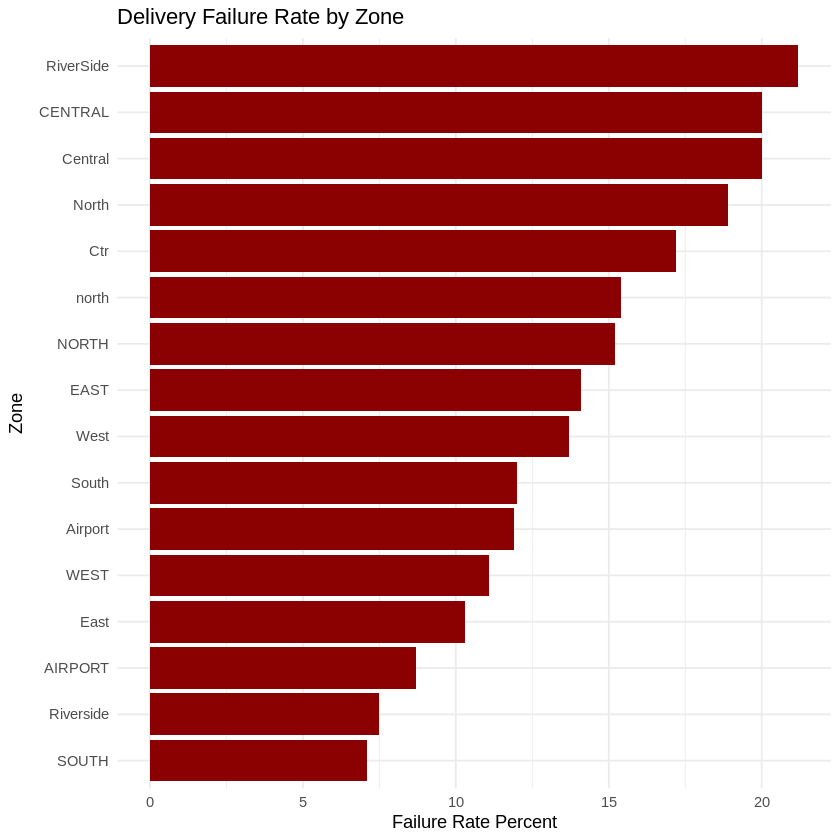

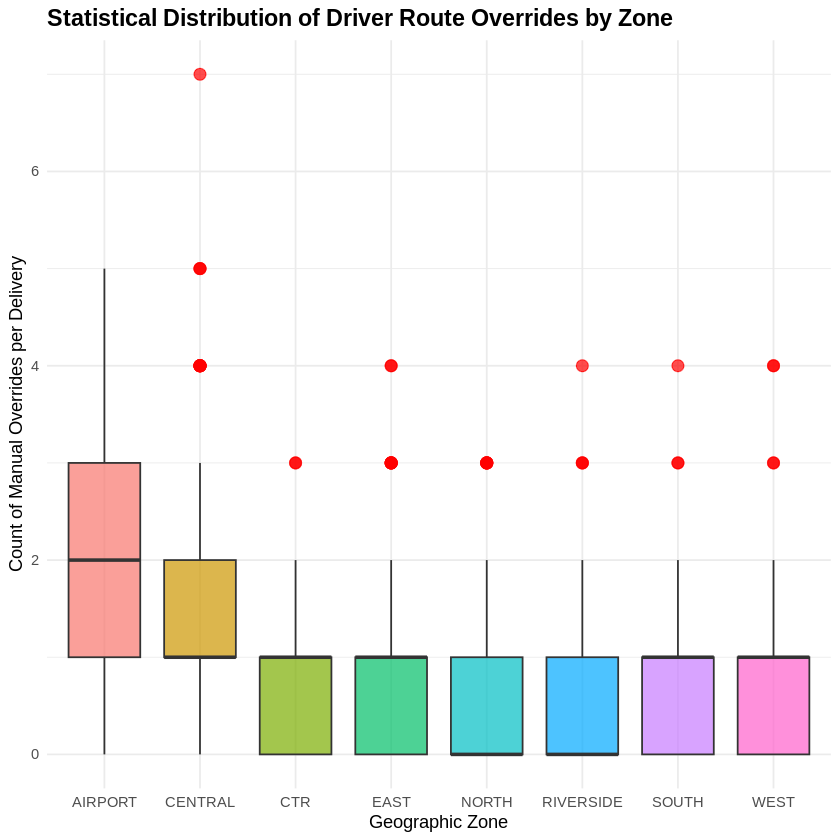

In [1]:

install.packages("sqldf")
library(sqldf)
library(dplyr)
library(ggplot2)

link_deliveries = "https://raw.githubusercontent.com/AnjoCaido6/NorthStar_Databases_Analytics/refs/heads/main/deliveries.csv"
link_orders = "https://raw.githubusercontent.com/AnjoCaido6/NorthStar_Databases_Analytics/refs/heads/main/orders.csv"
link_hubs = "https://raw.githubusercontent.com/AnjoCaido6/NorthStar_Databases_Analytics/refs/heads/main/hubs.csv"
link_drivers = "https://raw.githubusercontent.com/AnjoCaido6/NorthStar_Databases_Analytics/refs/heads/main/drivers.csv"

deliveries = read.csv(link_deliveries)
orders = read.csv(link_orders)
hubs = read.csv(link_hubs)
drivers = read.csv(link_drivers)

# SQL Query 1
query_zone = sqldf("
  SELECT o.pickup_zone AS zone,
  COUNT(d.delivery_id) AS total_deliveries,
  SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed,
  ROUND(SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1.0 ELSE 0 END) / COUNT(*) * 100, 1) AS failure_rate_pct,
  ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_rating,
  ROUND(AVG(d.manual_route_override_count), 2) AS avg_overrides
  FROM deliveries d
  LEFT JOIN orders o ON d.order_id = o.order_id
  WHERE o.pickup_zone IS NOT NULL
  GROUP BY o.pickup_zone
  ORDER BY failure_rate_pct DESC
")
print(query_zone)


# SQL Query 2
query_hub = sqldf("
  SELECT h.hub_name, h.zone, h.capacity_score,
  COUNT(d.delivery_id) AS total_dispatches,
  ROUND(SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1.0 ELSE 0 END) / COUNT(*) * 100, 1) AS failure_pct
  FROM deliveries d
  LEFT JOIN hubs h ON d.hub_id = h.hub_id
  GROUP BY h.hub_id
  ORDER BY failure_pct DESC
")
print(query_hub)


# SQL Query 3
query_override = sqldf("
  SELECT d.driver_id, dr.training_score,
  COUNT(d.delivery_id) AS total_deliveries,
  ROUND(AVG(d.manual_route_override_count), 2) AS avg_overrides
  FROM deliveries d
  LEFT JOIN drivers dr ON d.driver_id = dr.driver_id
  GROUP BY d.driver_id
  HAVING total_deliveries > 5
  ORDER BY avg_overrides DESC
  LIMIT 10
")
print(query_override)


# SQL Query 4
query_financial = sqldf("
  SELECT o.service_type,
  COUNT(d.delivery_id) AS total_deliveries,
  ROUND(AVG(o.order_value), 2) AS avg_revenue,
  ROUND(AVG(d.fuel_or_charge_cost), 2) AS avg_cost,
  ROUND(AVG(d.fuel_or_charge_cost) / AVG(o.order_value) * 100, 1) AS cost_pct,
  ROUND(SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1.0 ELSE 0 END) / COUNT(*) * 100, 1) AS failure_pct
  FROM deliveries d
  LEFT JOIN orders o ON d.order_id = o.order_id
  WHERE o.service_type IS NOT NULL
  GROUP BY o.service_type
  ORDER BY failure_pct DESC
")
print(query_financial)


df_main = left_join(deliveries, drivers, by = "driver_id")

driver_stats = df_main %>% group_by(driver_id) %>%
  summarise(training_score = first(training_score), deliveries = n(),
  failures = sum(delivery_status == 'Failed')) %>%
  mutate(failure_rate = failures / deliveries * 100) %>% filter(deliveries >= 5)

cor_result = cor.test(driver_stats$training_score, driver_stats$failure_rate, method = "spearman")
print(cor_result)


ggplot(query_zone, aes(x = reorder(zone, failure_rate_pct), y = failure_rate_pct)) +
  geom_bar(stat = "identity", fill = "darkred") + coord_flip() +
  labs(title = "Delivery Failure Rate by Zone", x = "Zone", y = "Failure Rate Percent") + theme_minimal()


library(ggplot2)


df_fleet <- merge(deliveries, orders, by="order_id", all.x=TRUE)


df_fleet$pickup_zone <- toupper(trimws(df_fleet$pickup_zone))


ggplot(df_fleet, aes(x = pickup_zone, y = manual_route_override_count, fill = pickup_zone)) +
  geom_boxplot(alpha = 0.7, outlier.colour = "red", outlier.size = 3) +
  theme_minimal() +
  labs(
    title = "Statistical Distribution of Driver Route Overrides by Zone",
    x = "Geographic Zone",
    y = "Count of Manual Overrides per Delivery"
  ) +
  theme(
    plot.title = element_text(face = "bold", size = 14),
    legend.position = "none"
  )